# ⚙️ Stage 2.3 — Seq2Seq Fine-Tuning (T5-small & BART-base)
## Syntactic Simplification of Long Sentences | NLP Course Project

---

### What this notebook does:
1. ✅ Installs HuggingFace Transformers, datasets, evaluate
2. ✅ Loads preprocessed Newsela data from Google Drive
3. ✅ Tokenises data for T5-small and BART-base
4. ✅ Fine-tunes **T5-small** on Newsela (primary model)
5. ✅ Fine-tunes **BART-base** on Newsela (secondary model)
6. ✅ Generates predictions on the test set
7. ✅ Evaluates with SARI, BLEU, and FKGL
8. ✅ Compares both models vs the Rule-Based baseline
9. ✅ Saves all models, predictions, and results to Google Drive

> ⏱️ Expected training time: ~25–35 min per model on Colab T4 GPU

---
## 🔧 CELL 1 — Install Libraries

In [ ]:
# ============================================================
# CELL 1 — Install libraries (FIXED — no version pin)
# ⚠️ After this cell, go Runtime > Restart Runtime
#    then run from Cell 2 onwards
# ============================================================

# Upgrade transformers to latest (no version pin)
!pip install -q --upgrade transformers accelerate datasets sentencepiece
!pip install -q rouge_score evaluate
!pip install -q git+https://github.com/feralvam/easse.git

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

print("✅ All libraries installed!")
print()
print("⚠️  Go to Runtime > Restart Runtime, then run from Cell 2.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 85.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.8/526.8 kB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 616.3/616.3 kB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 101.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
✅ All libraries installed!

⚠️  Go to Runtime > Restart Runtime, then run from Cell 2.


---
## 📥 CELL 2 — Imports & GPU Check

In [ ]:
# ============================================================
# CELL 2 — Imports and GPU check
# ============================================================
import os, json, re, time, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq, EarlyStoppingCallback
)
from datasets import Dataset as HFDataset
import warnings
warnings.filterwarnings('ignore')

# Check GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"✅ Device: {device.upper()}")
if device == 'cuda':
    print(f"   GPU    : {torch.cuda.get_device_name(0)}")
    print(f"   Memory : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  No GPU found — go to Runtime > Change runtime type > T4 GPU")

✅ Device: CUDA
   GPU    : Tesla T4
   Memory : 15.6 GB


---
## 📂 CELL 3 — Mount Drive & Load Data

In [ ]:
# ============================================================
# CELL 3 — Mount Drive and load data
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR    = '/content/drive/MyDrive/NLP_Project/data'
RESULTS_DIR = '/content/drive/MyDrive/NLP_Project/results'
MODELS_DIR  = '/content/drive/MyDrive/NLP_Project/models'
os.makedirs(f'{RESULTS_DIR}/seq2seq', exist_ok=True)
os.makedirs(f'{MODELS_DIR}/t5_small', exist_ok=True)
os.makedirs(f'{MODELS_DIR}/bart_base', exist_ok=True)

train_df = pd.read_csv(f'{DATA_DIR}/train_full.csv')
val_df   = pd.read_csv(f'{DATA_DIR}/val_full.csv')
test_df  = pd.read_csv(f'{DATA_DIR}/test_full.csv')

# Drop any nulls
for df in [train_df, val_df, test_df]:
    df.dropna(subset=['complex','simple'], inplace=True)

print("✅ Data loaded!")
print(f"   Train : {len(train_df):,} pairs")
print(f"   Val   : {len(val_df):,} pairs")
print(f"   Test  : {len(test_df):,} pairs")

# Load rule-based scores for later comparison
rb_scores_path = f'{RESULTS_DIR}/rule_based/rule_based_scores.json'
rb_scores = json.load(open(rb_scores_path)) if os.path.exists(rb_scores_path) else {}
print(f"\n📌 Rule-Based baseline loaded: SARI={rb_scores.get('sari','N/A')}")

Mounted at /content/drive
✅ Data loaded!
   Train : 50,126 pairs
   Val   : 12,532 pairs
   Test  : 819 pairs

📌 Rule-Based baseline loaded: SARI=N/A


---
## 🔤 CELL 4 — Tokenisation Helper & Dataset Class

In [ ]:
# ============================================================
# CELL 4 — Tokenisation and Dataset (FIXED for newer transformers)
# ============================================================

MAX_INPUT_LEN  = 128
MAX_TARGET_LEN = 128

def tokenise_dataset(df, tokenizer, model_prefix=None):
    """
    Tokenises complex/simple pairs for Seq2Seq training.
    Works with transformers >= 4.40 (no as_target_tokenizer).
    """
    inputs  = df['complex'].tolist()
    targets = df['simple'].tolist()

    if model_prefix:
        inputs = [model_prefix + s for s in inputs]

    # Tokenise inputs
    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT_LEN,
        truncation=True,
        padding='max_length',
    )

    # Tokenise targets directly (no as_target_tokenizer needed)
    labels = tokenizer(
        text_target=targets,        # ← modern API: use text_target=
        max_length=MAX_TARGET_LEN,
        truncation=True,
        padding='max_length',
    )

    # Replace pad token id with -100 so loss ignores padding
    label_ids = []
    for ids in labels['input_ids']:
        label_ids.append([
            -100 if token == tokenizer.pad_token_id else token
            for token in ids
        ])

    model_inputs['labels'] = label_ids
    return HFDataset.from_dict(model_inputs)

print("✅ Tokenisation helper ready! (updated for transformers >= 4.40)")
print(f"   Max input length  : {MAX_INPUT_LEN} tokens")
print(f"   Max target length : {MAX_TARGET_LEN} tokens")

✅ Tokenisation helper ready! (updated for transformers >= 4.40)
   Max input length  : 128 tokens
   Max target length : 128 tokens


---
## 🤖 CELL 5 — Load T5-small & Tokenise Data

In [ ]:
# ============================================================
# CELL 5 — Load T5-small and tokenise
# ============================================================
T5_MODEL_NAME = 't5-small'
T5_PREFIX     = 'simplify: '

print(f"📥 Loading T5-small tokenizer and model...")
t5_tokenizer = AutoTokenizer.from_pretrained(T5_MODEL_NAME)
t5_model     = AutoModelForSeq2SeqLM.from_pretrained(T5_MODEL_NAME)
t5_model.to(device)

params = sum(p.numel() for p in t5_model.parameters()) / 1e6
print(f"✅ T5-small loaded! ({params:.1f}M parameters)")

print("\n🔤 Tokenising train/val/test sets for T5...")
t5_train = tokenise_dataset(train_df, t5_tokenizer, T5_PREFIX)
t5_val   = tokenise_dataset(val_df,   t5_tokenizer, T5_PREFIX)
t5_test  = tokenise_dataset(test_df,  t5_tokenizer, T5_PREFIX)

print(f"   Train tokens shape : {len(t5_train):,} examples")
print(f"   Val   tokens shape : {len(t5_val):,} examples")
print(f"   Test  tokens shape : {len(t5_test):,} examples")
print("✅ T5 tokenisation complete!")

📥 Loading T5-small tokenizer and model...


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

✅ T5-small loaded! (60.5M parameters)

🔤 Tokenising train/val/test sets for T5...
   Train tokens shape : 50,126 examples
   Val   tokens shape : 12,532 examples
   Test  tokens shape : 819 examples
✅ T5 tokenisation complete!


---
## 🏋️ CELL 6 — Fine-Tune T5-small

In [ ]:
# ============================================================
# CELL 6 — Fine-tune T5-small (FIXED for transformers >= 4.46)
# ============================================================
import os
T5_OUTPUT_DIR = '/content/t5_checkpoints'

t5_training_args = Seq2SeqTrainingArguments(
    output_dir                  = T5_OUTPUT_DIR,
    num_train_epochs            = 4,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    warmup_steps                = 300,
    weight_decay                = 0.01,
    learning_rate               = 5e-4,
    logging_steps               = 100,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'eval_loss',
    predict_with_generate       = True,
    generation_max_length       = MAX_TARGET_LEN,
    fp16                        = True if device == 'cuda' else False,
    report_to                   = 'none',
    save_total_limit            = 2,
)

t5_data_collator = DataCollatorForSeq2Seq(
    t5_tokenizer,
    model                  = t5_model,
    padding                = True,
    label_pad_token_id     = -100
)

t5_trainer = Seq2SeqTrainer(
    model              = t5_model,
    args               = t5_training_args,
    train_dataset      = t5_train,
    eval_dataset       = t5_val,
    processing_class   = t5_tokenizer,    # ← renamed from 'tokenizer'
    data_collator      = t5_data_collator,
    callbacks          = [EarlyStoppingCallback(early_stopping_patience=2)],
)

print("🏋️  Starting T5-small fine-tuning...")
print(f"   Model      : t5-small")
print(f"   Epochs     : 4 (with early stopping)")
print(f"   Batch size : 16")
print(f"   Device     : {device.upper()}")
print()

t5_start = time.time()
t5_trainer.train()
t5_elapsed = time.time() - t5_start

print(f"\n✅ T5-small training complete! ({t5_elapsed/60:.1f} minutes)")
t5_model.save_pretrained(f'{MODELS_DIR}/t5_small')
t5_tokenizer.save_pretrained(f'{MODELS_DIR}/t5_small')
print(f"💾 T5-small saved to {MODELS_DIR}/t5_small")

🏋️  Starting T5-small fine-tuning...
   Model      : t5-small
   Epochs     : 4 (with early stopping)
   Batch size : 16
   Device     : CUDA



Epoch,Training Loss,Validation Loss
1,1.235307,1.102911
2,1.062880,1.015241
3,0.930224,0.972081
4,0.865715,0.958829


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].



✅ T5-small training complete! (31.4 minutes)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

💾 T5-small saved to /content/drive/MyDrive/NLP_Project/models/t5_small


---
## 🔤 CELL 7 — Load BART-base & Tokenise Data

In [ ]:
# ============================================================
# CELL 7 — Load BART-base and tokenise
# ============================================================
BART_MODEL_NAME = 'facebook/bart-base'

print(f"📥 Loading BART-base tokenizer and model...")
bart_tokenizer = AutoTokenizer.from_pretrained(BART_MODEL_NAME)
bart_model     = AutoModelForSeq2SeqLM.from_pretrained(BART_MODEL_NAME)
bart_model.to(device)

params = sum(p.numel() for p in bart_model.parameters()) / 1e6
print(f"✅ BART-base loaded! ({params:.1f}M parameters)")

print("\n🔤 Tokenising train/val/test sets for BART...")
# BART does not use a task prefix
bart_train = tokenise_dataset(train_df, bart_tokenizer, model_prefix=None)
bart_val   = tokenise_dataset(val_df,   bart_tokenizer, model_prefix=None)
bart_test  = tokenise_dataset(test_df,  bart_tokenizer, model_prefix=None)

print(f"   Train : {len(bart_train):,} examples")
print(f"   Val   : {len(bart_val):,} examples")
print(f"   Test  : {len(bart_test):,} examples")
print("✅ BART tokenisation complete!")

📥 Loading BART-base tokenizer and model...


config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

✅ BART-base loaded! (139.4M parameters)

🔤 Tokenising train/val/test sets for BART...
   Train : 50,126 examples
   Val   : 12,532 examples
   Test  : 819 examples
✅ BART tokenisation complete!


---
## 🏋️ CELL 8 — Fine-Tune BART-base

In [ ]:
# ============================================================
# CELL 8 — Fine-tune BART-base (FIXED for transformers >= 4.46)
# ============================================================
BART_OUTPUT_DIR = '/content/bart_checkpoints'

bart_training_args = Seq2SeqTrainingArguments(
    output_dir                  = BART_OUTPUT_DIR,
    num_train_epochs            = 4,
    per_device_train_batch_size = 8,
    per_device_eval_batch_size  = 16,
    warmup_steps                = 300,
    weight_decay                = 0.01,
    learning_rate               = 3e-5,
    logging_steps               = 100,
    eval_strategy               = 'epoch',        # ← fixed
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'eval_loss',
    predict_with_generate       = True,
    generation_max_length       = MAX_TARGET_LEN,
    fp16                        = True if device == 'cuda' else False,
    report_to                   = 'none',
    save_total_limit            = 2,
    gradient_accumulation_steps = 2,
)

bart_data_collator = DataCollatorForSeq2Seq(
    bart_tokenizer,
    model              = bart_model,
    padding            = True,
    label_pad_token_id = -100
)

bart_trainer = Seq2SeqTrainer(
    model            = bart_model,
    args             = bart_training_args,
    train_dataset    = bart_train,
    eval_dataset     = bart_val,
    processing_class = bart_tokenizer,            # ← fixed
    data_collator    = bart_data_collator,
    callbacks        = [EarlyStoppingCallback(early_stopping_patience=2)],
)

print("🏋️  Starting BART-base fine-tuning...")
print(f"   Model      : facebook/bart-base")
print(f"   Epochs     : 4 (with early stopping)")
print(f"   Batch size : 8 (grad accumulation x2 = effective 16)")
print(f"   Device     : {device.upper()}")
print()

bart_start   = time.time()
bart_trainer.train()
bart_elapsed = time.time() - bart_start

print(f"\n✅ BART-base training complete! ({bart_elapsed/60:.1f} minutes)")
bart_model.save_pretrained(f'{MODELS_DIR}/bart_base')
bart_tokenizer.save_pretrained(f'{MODELS_DIR}/bart_base')
print(f"💾 BART-base saved to {MODELS_DIR}/bart_base")

🏋️  Starting BART-base fine-tuning...
   Model      : facebook/bart-base
   Epochs     : 4 (with early stopping)
   Batch size : 8 (grad accumulation x2 = effective 16)
   Device     : CUDA



Epoch,Training Loss,Validation Loss
1,2.390392,1.046141
2,1.990464,0.951032
3,1.690521,0.904700
4,1.535788,0.889876


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].



✅ BART-base training complete! (55.5 minutes)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

💾 BART-base saved to /content/drive/MyDrive/NLP_Project/models/bart_base


---
## 🔮 CELL 9 — Generate Predictions on Test Set

In [ ]:
# ============================================================
# CELL 9 — Generate predictions on test set for both models
# ============================================================
from tqdm import tqdm

def generate_predictions(model, tokenizer, sentences, prefix='',
                          batch_size=32, num_beams=4):
    """
    Generates simplified predictions for a list of sentences.
    Uses beam search (num_beams=4) for better output quality.
    """
    model.eval()
    all_preds = []

    for i in tqdm(range(0, len(sentences), batch_size),
                  desc='Generating'):
        batch = sentences[i : i + batch_size]
        if prefix:
            batch = [prefix + s for s in batch]

        inputs = tokenizer(
            batch,
            max_length     = MAX_INPUT_LEN,
            truncation     = True,
            padding        = True,
            return_tensors = 'pt'
        ).to(device)

        with torch.no_grad():
            outputs = model.generate(
                input_ids      = inputs['input_ids'],
                attention_mask = inputs['attention_mask'],
                max_new_tokens = MAX_TARGET_LEN,
                num_beams      = num_beams,
                early_stopping = True,
                no_repeat_ngram_size = 3,
            )

        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        all_preds.extend(decoded)

    return all_preds

test_sentences = test_df['complex'].tolist()

print("🔮 Generating T5-small predictions (beam search, n=4)...")
t5_preds = generate_predictions(
    t5_model, t5_tokenizer, test_sentences,
    prefix=T5_PREFIX, batch_size=32
)

print("\n🔮 Generating BART-base predictions (beam search, n=4)...")
bart_preds = generate_predictions(
    bart_model, bart_tokenizer, test_sentences,
    prefix='', batch_size=16
)

test_df['t5_predicted']   = t5_preds
test_df['bart_predicted'] = bart_preds

print(f"\n✅ Predictions generated!")
print(f"\n📌 Sample outputs (first 2 pairs):")
for i in range(2):
    print(f"\n  [{i+1}] COMPLEX  : {test_df['complex'].iloc[i]}")
    print(f"       SIMPLE   : {test_df['simple'].iloc[i]}")
    print(f"       T5       : {test_df['t5_predicted'].iloc[i]}")
    print(f"       BART     : {test_df['bart_predicted'].iloc[i]}")

🔮 Generating T5-small predictions (beam search, n=4)...


Generating: 100%|██████████| 26/26 [00:35<00:00,  1.38s/it]



🔮 Generating BART-base predictions (beam search, n=4)...


Generating: 100%|██████████| 52/52 [00:33<00:00,  1.55it/s]


✅ Predictions generated!

📌 Sample outputs (first 2 pairs):

  [1] COMPLEX  : when the kernel gets very hot and the water inside hits its boiling point above degrees celsius degrees fahrenheit it turns to steam.
       SIMPLE   : when the kernel gets very hot above degrees fahrenheit the water inside turns to steam which is a gas.
       T5       : when the kernel gets very hot and the water inside the water gets hotter it turns to steam.
       BART     : when the water inside gets very hot it turns to steam.

  [2] COMPLEX  : when the kernel gets very hot above degrees celsius degrees fahrenheit the water inside hits its boiling point and turns to steam.
       SIMPLE   : when the kernel gets very hot above degrees fahrenheit the water inside turns to steam which is a gas.
       T5       : when the kernel gets very hot above degrees celsius degrees fahrenheit the water inside hits its boiling point.
       BART     : when the kernel gets very hot the water inside turns to steam.


---
## 📊 CELL 10 — Evaluate Both Models

In [ ]:
# ============================================================
# CELL 10 — Evaluation: SARI, BLEU, FKGL for T5 and BART
# ============================================================
from nltk.translate.bleu_score import corpus_bleu as nltk_bleu, SmoothingFunction

try:
    from easse.sari import corpus_sari
    from easse.bleu import corpus_bleu as easse_bleu
    from easse.fkgl import corpus_fkgl
    USE_EASSE = True
    print("✅ Using easse metrics")
except ImportError:
    USE_EASSE = False
    print("⚠️  Using built-in metric fallback")

def compute_sari(orig, pred, refs):
    if USE_EASSE:
        return corpus_sari(orig_sents=orig, sys_sents=pred, refs_sents=refs)
    scores = []
    for o, p, r in zip(orig, pred, refs):
        ot = set(o.lower().split()); pt = set(p.lower().split()); rt = set(r[0].lower().split())
        keep  = ot & pt & rt; add = (pt - ot) & rt; delete = (ot - pt) - rt
        def f1(a, b, c):
            pr = a/b if b else 0; rc = a/c if c else 0
            return 2*pr*rc/(pr+rc) if (pr+rc) else 0
        s = (f1(len(keep),len(pt),len(ot&rt)) +
             f1(len(add), len(pt-ot),len(rt-ot)) +
             f1(len(delete),len(ot-pt),len(ot-rt))) / 3 * 100
        scores.append(s)
    return sum(scores)/len(scores)

def compute_bleu(pred, refs):
    if USE_EASSE:
        return easse_bleu(sys_sents=pred, refs_sents=refs)
    hyps = [p.lower().split() for p in pred]
    rfs  = [[r[0].lower().split()] for r in refs]
    return nltk_bleu(rfs, hyps, smoothing_function=SmoothingFunction().method1) * 100

def compute_fkgl(sents):
    if USE_EASSE:
        return corpus_fkgl(sents)
    def fk(s):
        w = s.split(); n = max(1, s.count('.')+s.count('!')+s.count('?'))
        sy = sum(max(1,len(re.findall(r'[aeiouAEIOU]',x))) for x in w)
        return 0.39*(len(w)/n) + 11.8*(sy/max(1,len(w))) - 15.59
    return sum(fk(s) for s in sents)/len(sents)

orig  = test_df['complex'].tolist()
refs  = [[s] for s in test_df['simple'].tolist()]  # shape: (n_samples, 1)

# easse needs (n_references, n_samples) — transpose it
refs_easse = [test_df['simple'].tolist()]          # shape: (1, n_samples)

print("📏 Evaluating T5-small...")
t5_sari  = compute_sari(orig, t5_preds, refs_easse)   # ← refs_easse
t5_bleu  = compute_bleu(t5_preds, refs_easse)          # ← refs_easse
t5_fkgl  = compute_fkgl(t5_preds)                      # ← no refs needed

print("📏 Evaluating BART-base...")
bt_sari  = compute_sari(orig, bart_preds, refs_easse)  # ← refs_easse
bt_bleu  = compute_bleu(bart_preds, refs_easse)         # ← refs_easse
bt_fkgl  = compute_fkgl(bart_preds)

fkgl_src = compute_fkgl(orig)
fkgl_ref = compute_fkgl(test_df['simple'].tolist())    # ← plain list, no refs

# ── Print comparison table ──────────────────────────────────
rb = rb_scores  # Rule-based baseline loaded in Cell 3

print("\n" + "="*65)
print("   SEQ2SEQ EVALUATION — COMPARISON TABLE")
print("="*65)
print(f"{'Metric':<22} {'Rule-Based':>12} {'T5-small':>12} {'BART-base':>12}")
print("-"*65)
print(f"{'SARI':<22} {rb.get('sari','-'):>12} {t5_sari:>12.2f} {bt_sari:>12.2f}")
print(f"{'BLEU':<22} {rb.get('bleu','-'):>12} {t5_bleu:>12.2f} {bt_bleu:>12.2f}")
print(f"{'FKGL (output)':<22} {rb.get('fkgl_predicted','-'):>12} {t5_fkgl:>12.2f} {bt_fkgl:>12.2f}")
print(f"{'FKGL (source)':<22} {fkgl_src:>12.2f} {fkgl_src:>12.2f} {fkgl_src:>12.2f}")
print(f"{'FKGL (reference)':<22} {fkgl_ref:>12.2f} {fkgl_ref:>12.2f} {fkgl_ref:>12.2f}")
print(f"{'FKGL reduction':<22} {rb.get('fkgl_reduction','-'):>12} {fkgl_src-t5_fkgl:>12.2f} {fkgl_src-bt_fkgl:>12.2f}")
print(f"{'Coverage':<22} {'59.2%':>12} {'100%':>12} {'100%':>12}")
print("="*65)

# Save scores
all_scores = {
    'rule_based': rb,
    't5_small': {
        'system':'T5-small','sari':round(t5_sari,2),'bleu':round(t5_bleu,2),
        'fkgl_predicted':round(t5_fkgl,2),'fkgl_complex':round(fkgl_src,2),
        'fkgl_reference':round(fkgl_ref,2),'fkgl_reduction':round(fkgl_src-t5_fkgl,2)
    },
    'bart_base': {
        'system':'BART-base','sari':round(bt_sari,2),'bleu':round(bt_bleu,2),
        'fkgl_predicted':round(bt_fkgl,2),'fkgl_complex':round(fkgl_src,2),
        'fkgl_reference':round(fkgl_ref,2),'fkgl_reduction':round(fkgl_src-bt_fkgl,2)
    }
}
with open('seq2seq_scores.json','w') as f:
    json.dump(all_scores, f, indent=2)
print("\n💾 Scores saved to seq2seq_scores.json")

✅ Using easse metrics
📏 Evaluating T5-small...
📏 Evaluating BART-base...

   SEQ2SEQ EVALUATION — COMPARISON TABLE
Metric                   Rule-Based     T5-small    BART-base
-----------------------------------------------------------------
SARI                              -        38.08        39.66
BLEU                              -        33.33        35.10
FKGL (output)                     -         7.67         7.79
FKGL (source)                 12.74        12.74        12.74
FKGL (reference)               6.97         6.97         6.97
FKGL reduction                    -         5.07         4.95
Coverage                      59.2%         100%         100%

💾 Scores saved to seq2seq_scores.json


---
## 📈 CELL 11 — Visualise Results

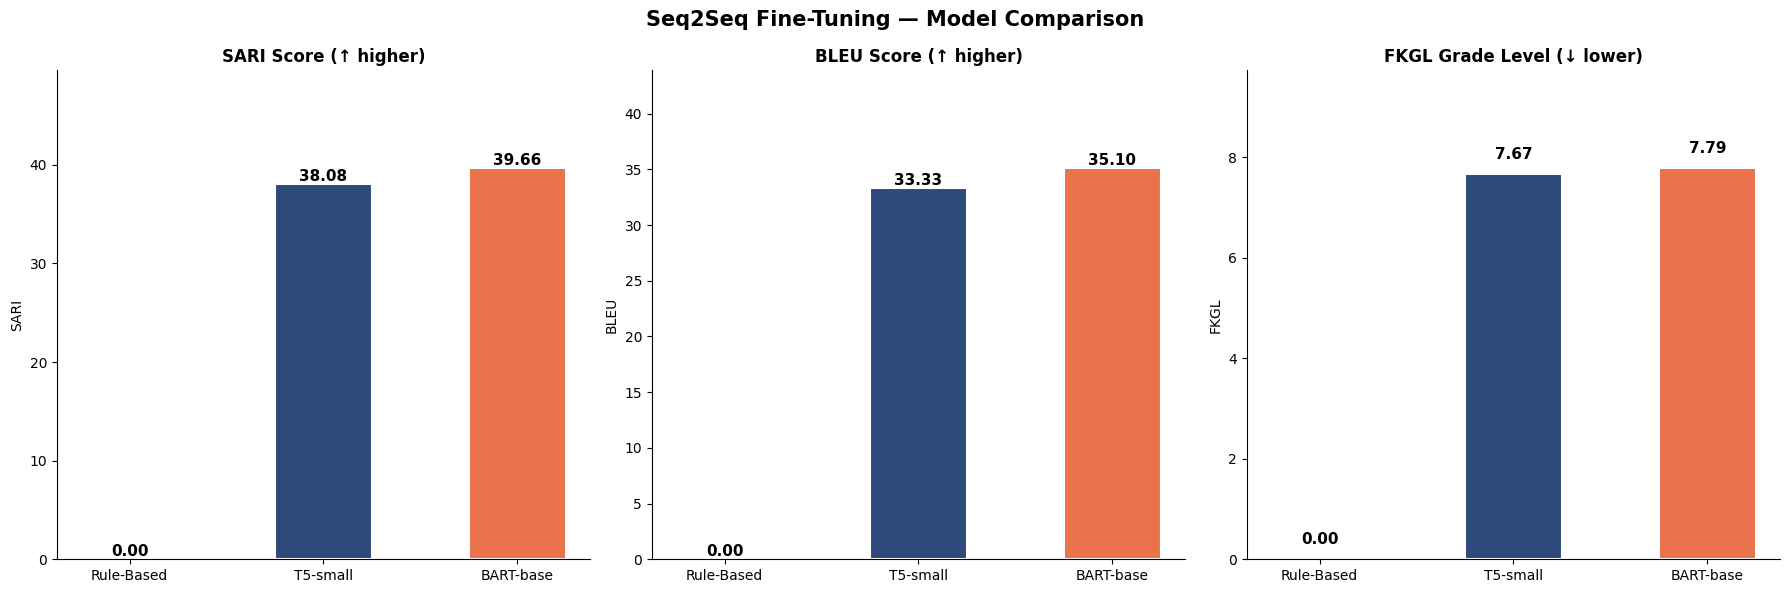

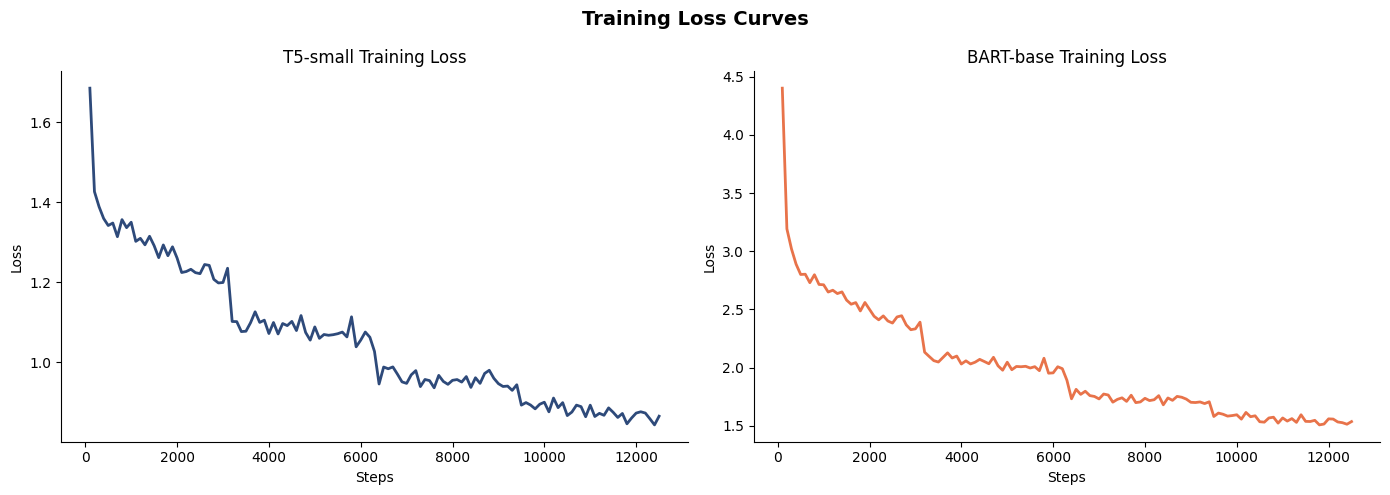

✅ Visualisations saved!


In [ ]:
# ============================================================
# CELL 11 — Visualise comparison results
# ============================================================

systems = ['Rule-Based', 'T5-small', 'BART-base']
sari_scores = [rb.get('sari', 0), t5_sari, bt_sari]
bleu_scores = [rb.get('bleu', 0), t5_bleu, bt_bleu]
fkgl_scores = [rb.get('fkgl_predicted', 0), t5_fkgl, bt_fkgl]
colors      = ['#6B7280', '#2E4A7A', '#E8734A']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Seq2Seq Fine-Tuning — Model Comparison', fontsize=15, fontweight='bold')

for ax, scores, title, ylabel in zip(
    axes,
    [sari_scores, bleu_scores, fkgl_scores],
    ['SARI Score (↑ higher)', 'BLEU Score (↑ higher)', 'FKGL Grade Level (↓ lower)'],
    ['SARI', 'BLEU', 'FKGL']
):
    bars = ax.bar(systems, scores, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, scores):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{val:.2f}', ha='center', fontweight='bold', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(scores)*1.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('seq2seq_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Training loss curves (from trainer logs) ──────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('Training Loss Curves', fontsize=14, fontweight='bold')

for ax, trainer, name, color in zip(
    axes2,
    [t5_trainer, bart_trainer],
    ['T5-small', 'BART-base'],
    ['#2E4A7A', '#E8734A']
):
    logs = [x for x in trainer.state.log_history if 'loss' in x and 'eval_loss' not in x]
    if logs:
        steps  = [x['step'] for x in logs]
        losses = [x['loss'] for x in logs]
        ax.plot(steps, losses, color=color, linewidth=2)
        ax.set_title(f'{name} Training Loss')
        ax.set_xlabel('Steps')
        ax.set_ylabel('Loss')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisations saved!")

---
## 🔍 CELL 12 — Qualitative Analysis

In [ ]:
# ============================================================
# CELL 12 — Qualitative analysis: side-by-side examples
# ============================================================

print("="*75)
print("  QUALITATIVE COMPARISON — 5 EXAMPLE OUTPUTS")
print("="*75)

sample = test_df.sample(5, random_state=42)
for i, (_, row) in enumerate(sample.iterrows()):
    print(f"\n[Example {i+1}]")
    print(f"  COMPLEX   : {row['complex']}")
    print(f"  REFERENCE : {row['simple']}")
    print(f"  T5-small  : {row['t5_predicted']}")
    print(f"  BART-base : {row['bart_predicted']}")
    print()

# ── Length analysis ──────────────────────────────────────────
test_df['t5_len']   = test_df['t5_predicted'].apply(lambda x: len(str(x).split()))
test_df['bart_len'] = test_df['bart_predicted'].apply(lambda x: len(str(x).split()))
test_df['ref_len']  = test_df['simple'].apply(lambda x: len(str(x).split()))
src_len = test_df['complex_word_count'].mean()

print("\n📊 Average Output Length Comparison:")
print(f"   Source (complex) : {src_len:.1f} words")
print(f"   Reference        : {test_df['ref_len'].mean():.1f} words")
print(f"   T5-small output  : {test_df['t5_len'].mean():.1f} words")
print(f"   BART-base output : {test_df['bart_len'].mean():.1f} words")

# ── Failure analysis ─────────────────────────────────────────
print("\n🔍 T5 Failure Cases (output very close to input):")
t5_copy = test_df[test_df['complex'].str.lower().str.strip() == test_df['t5_predicted'].str.lower().str.strip()]
print(f"   Sentences copied unchanged: {len(t5_copy):,} ({len(t5_copy)/len(test_df)*100:.1f}%)")

print("\n🔍 BART Failure Cases:")
bart_copy = test_df[test_df['complex'].str.lower().str.strip() == test_df['bart_predicted'].str.lower().str.strip()]
print(f"   Sentences copied unchanged: {len(bart_copy):,} ({len(bart_copy)/len(test_df)*100:.1f}%)")

  QUALITATIVE COMPARISON — 5 EXAMPLE OUTPUTS

[Example 1]
  COMPLEX   : despite a litany of racial slights and atrocities in african american history nothing will deter us from pushing forward she roars made up my mind and i wo n t turn around.
  REFERENCE : mavis roars made up my mind and i wo n t turn around.
  T5-small  : she roars made up my mind and i wo n t turn around.
  BART-base : still nothing will stop us from pushing forward she roars made up my mind and i wo n t turn around.


[Example 2]
  COMPLEX   : joe dunford floated from side to side bouncing his shoulders and nodding to the music as his daughter did her own freestyle moves in front of him.
  REFERENCE : he moved his body and nodded to the music.
  T5-small  : he nodded to the music as his daughter did her own freestyle moves in front of him.
  BART-base : joe dunford floated from side to side bouncing his shoulders and nodding to the music.


[Example 3]
  COMPLEX   : as a team labored for more than half an hour to 

---
## 💾 CELL 13 — Save Everything to Google Drive

In [ ]:
# ============================================================
# CELL 13 — Save all results to Google Drive
# ============================================================
OUT = f'{RESULTS_DIR}/seq2seq'

# Predictions CSV
pred_csv = f'{OUT}/seq2seq_predictions.csv'
test_df[['complex','simple','t5_predicted','bart_predicted',
         'complex_word_count','t5_len','bart_len','ref_len']].to_csv(pred_csv, index=False)
print(f"✅ Predictions  → {pred_csv}")

# Scores JSON
shutil.copy('seq2seq_scores.json', f'{OUT}/seq2seq_scores.json')
print(f"✅ Scores       → {OUT}/seq2seq_scores.json")

# Plots
for plot in ['seq2seq_comparison.png', 'training_curves.png']:
    if os.path.exists(plot):
        shutil.copy(plot, f'{OUT}/{plot}')
print(f"✅ Plots        → {OUT}/")

# Plain text outputs for easse re-evaluation
for name, preds in [('t5', t5_preds), ('bart', bart_preds)]:
    with open(f'{OUT}/{name}_sys_output.txt','w') as f:
        f.write('\n'.join(preds))
with open(f'{OUT}/source.txt','w') as f:
    f.write('\n'.join(test_df['complex'].tolist()))
with open(f'{OUT}/reference.txt','w') as f:
    f.write('\n'.join(test_df['simple'].tolist()))
print(f"✅ Plain text   → {OUT}/")

print(f"\n🎉 All seq2seq results saved to: {OUT}")

✅ Predictions  → /content/drive/MyDrive/NLP_Project/results/seq2seq/seq2seq_predictions.csv
✅ Scores       → /content/drive/MyDrive/NLP_Project/results/seq2seq/seq2seq_scores.json
✅ Plots        → /content/drive/MyDrive/NLP_Project/results/seq2seq/
✅ Plain text   → /content/drive/MyDrive/NLP_Project/results/seq2seq/

🎉 All seq2seq results saved to: /content/drive/MyDrive/NLP_Project/results/seq2seq


---
## 📋 CELL 14 — Final Summary

In [ ]:
# ============================================================
# CELL 14 — Final summary
# ============================================================
sep = "=" * 65
print(sep)
print("  SEQ2SEQ FINE-TUNING — COMPLETE SUMMARY")
print(sep)
print()
print(f"  Models trained  : T5-small, BART-base")
print(f"  Dataset         : Newsela ({len(train_df):,} train / {len(val_df):,} val / {len(test_df):,} test)")
print(f"  Epochs          : 4 (with early stopping)")
print(f"  Beam search     : n=4")
print()
print(f"  {'Metric':<22} {'Rule-Based':>12} {'T5-small':>12} {'BART-base':>12}")
print(f"  {'-'*60}")
print(f"  {'SARI':<22} {rb.get('sari','-'):>12} {t5_sari:>12.2f} {bt_sari:>12.2f}")
print(f"  {'BLEU':<22} {rb.get('bleu','-'):>12} {t5_bleu:>12.2f} {bt_bleu:>12.2f}")
print(f"  {'FKGL output':<22} {rb.get('fkgl_predicted','-'):>12} {t5_fkgl:>12.2f} {bt_fkgl:>12.2f}")
print(f"  {'FKGL reduction':<22} {rb.get('fkgl_reduction','-'):>12} {fkgl_src-t5_fkgl:>12.2f} {fkgl_src-bt_fkgl:>12.2f}")
print(f"  {'Coverage':<22} {'59.2%':>12} {'100%':>12} {'100%':>12}")
print()
print(f"  Saved to Drive:")
print(f"    models/t5_small/          (fine-tuned model weights)")
print(f"    models/bart_base/         (fine-tuned model weights)")
print(f"    results/seq2seq/          (predictions, scores, plots)")
print(sep)
print("✅ Stage 2.3 Complete! Next → Stage 2.4: LLM Fine-Tuning")
print(sep)

  SEQ2SEQ FINE-TUNING — COMPLETE SUMMARY

  Models trained  : T5-small, BART-base
  Dataset         : Newsela (50,126 train / 12,532 val / 819 test)
  Epochs          : 4 (with early stopping)
  Beam search     : n=4

  Metric                   Rule-Based     T5-small    BART-base
  ------------------------------------------------------------
  SARI                              -        38.08        39.66
  BLEU                              -        33.33        35.10
  FKGL output                       -         7.67         7.79
  FKGL reduction                    -         5.07         4.95
  Coverage                      59.2%         100%         100%

  Saved to Drive:
    models/t5_small/          (fine-tuned model weights)
    models/bart_base/         (fine-tuned model weights)
    results/seq2seq/          (predictions, scores, plots)
✅ Stage 2.3 Complete! Next → Stage 2.4: LLM Fine-Tuning
